In [13]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl

import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "figures/ClonalGenesCorrelations"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/SS2.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [158]:
parameters,io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(3371, 98) (27061, 2) shape of adata after filtering 


In [70]:
def compareSD(df, LabelsTesting, num_shuffles, label, gene):
    "For each gene compare the mean variances of a shuffled labeling to the observed labeling"
    LabelsTesting.loc[:,'gene_name'] = df[gene]
    mean_shuffled_variances = []
    observedlabel_var = LabelsTesting.groupby(label)['gene_name'].std()
    mean_observedlabel_variance = observedlabel_var.mean()
    # do the shuffling
    for i in range(num_shuffles):
        # create copy
        LabelsTestingCopy = LabelsTesting.copy(deep = True)
        #shuffle labels
        LabelsTestingCopy.loc[:, label] = np.random.permutation(LabelsTesting[label].values)
        # groupby by label and compute variance
        shuffled_variances = LabelsTestingCopy.groupby(label)['gene_name'].std()
        # Mean variance of every labeled group
        mean_shuffled_variances.append(shuffled_variances.mean())
    #make list into series TODO refactor to just add to a series?
    #This is the distribution of shuffled variances
    mean_shuffled_variances = pd.Series(mean_shuffled_variances)
    # Number of times shuffled variances are less than observed label variance, higher number would be intragroup variance is higher
    test = mean_shuffled_variances <= mean_observedlabel_variance
        # less equal to observed (i.e. True's) by the number of tests
        # stat of 1 would be that shuffled variances always less or equal, 0 would be shuffled variances always more 
        # this is a frequentist p value? kinda ... we'll call it a score
    gene_score = test.sum() / test.shape[0]
    return gene_score, gene, mean_shuffled_variances, mean_observedlabel_variance

In [15]:
selector = adata.obs[adata.obs['Exp_Labels'].str.contains('Activation')].index

df = df[df.index.isin(selector)]

In [16]:
adata_obs = adata.obs[adata.obs.index.isin(df.index)]

In [17]:
tests = pd.read_csv('../outputs/stats_tests/CLONE_tests_True_1000_10000_log')

In [18]:
tests.sort_values('score')

,Unnamed: 0,score,gene
718,718,0.0,IGHV5-51
696,696,0.0,IGHG2
259,259,0.0,JCHAIN
740,740,0.0,GATM
131,131,0.0,IGKV3D-20
...,...,...,...
831,831,1.0,CD300LF
411,411,1.0,AC092681.2
404,404,1.0,LRGUK
809,809,1.0,CCL4


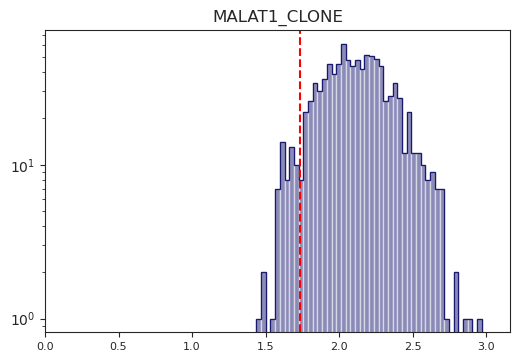

In [19]:
cs.plotTestHist(df, adata_obs, 1000, 'MALAT1', 'CLONE')

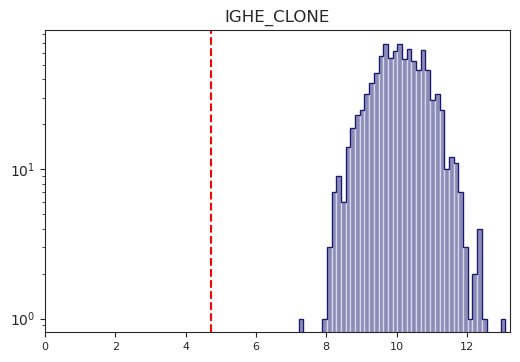

In [24]:
cs.plotTestHist(df, adata_obs, 1000, 'IGHE', 'CLONE')

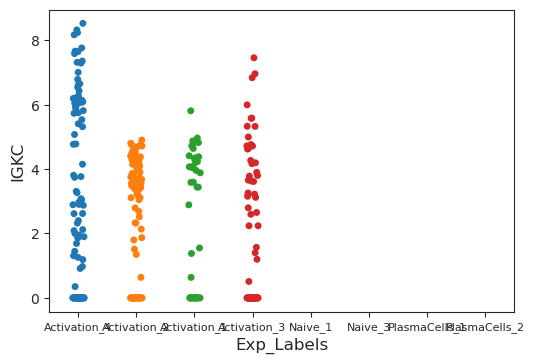

In [25]:
cs.plotWaterfall(df, adata.obs, 'IGKC', 'Exp_Labels')

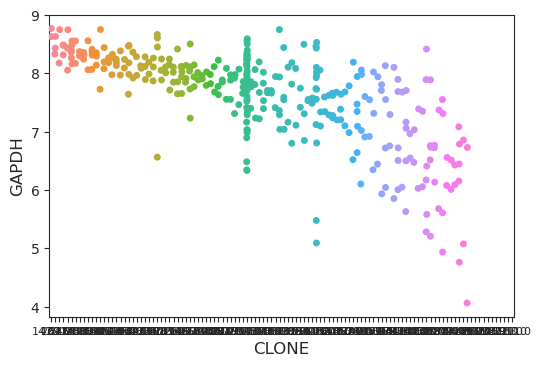

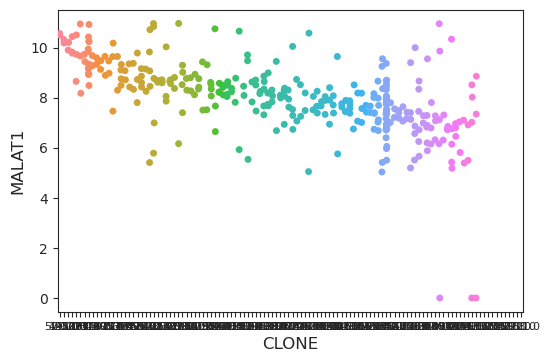

In [26]:
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'MALAT1', 'CLONE')

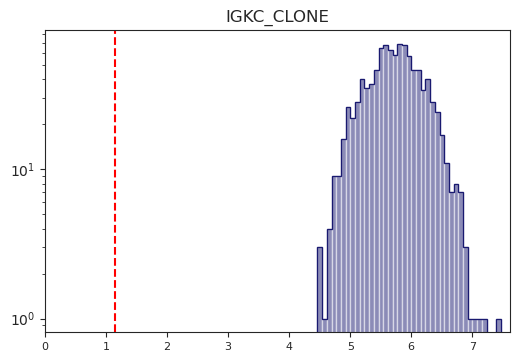

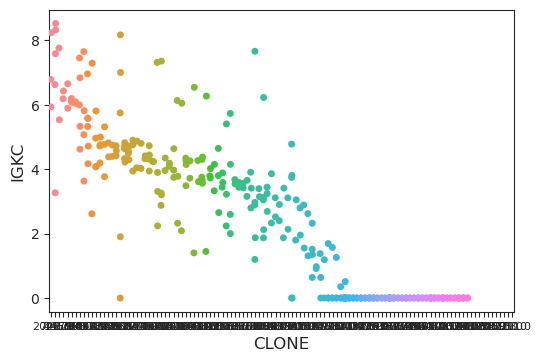

In [27]:
cs.plotTestHist(df, adata.obs, 1000, 'IGKC', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'IGKC', 'CLONE')

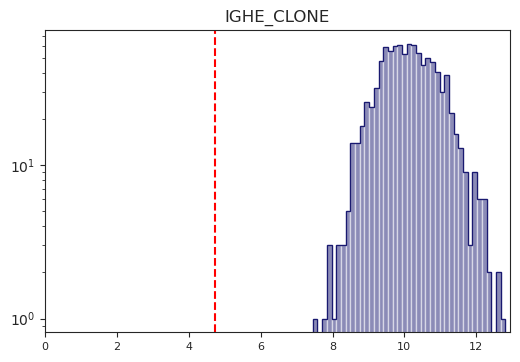

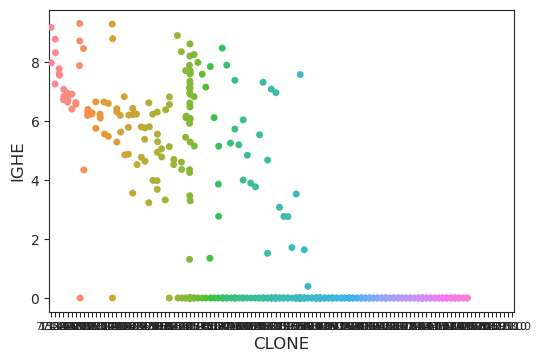

In [28]:
cs.plotTestHist(df, adata.obs, 1000, 'IGHE', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'IGHE', 'CLONE')

In [29]:
data, shuffled_means = cs.plotCI(df, adata, 1000, 'IGKC', 'CLONE', 0.2)

In [29]:
shuffled_means.mean(axis = 1) 

CLONE
2021.0    2.534188
746.0     2.469048
495.0     2.453024
1451.0    2.489899
579.0     2.387567
            ...   
1163.0    2.400307
1119.0    2.370117
1029.0    2.433377
593.0     2.480466
1241.0    2.468654
Length: 103, dtype: float32

In [35]:
shuffled_means.quantile(q = 0.975, axis = 1)

CLONE
2021.0    5.299187
746.0     4.520206
495.0     5.865648
1451.0    5.799511
579.0     5.759300
            ...   
1163.0    6.120767
1119.0    5.836534
1029.0    4.874450
593.0     5.309219
1241.0    5.747292
Name: 0.975, Length: 103, dtype: float64

In [37]:
shuffled_means.quantile(q = 0.025, axis = 1)

CLONE
2021.0    0.000000
746.0     0.530116
495.0     0.000000
1451.0    0.000000
579.0     0.000000
            ...   
1163.0    0.000000
1119.0    0.000000
1029.0    0.000000
593.0     0.000000
1241.0    0.000000
Name: 0.025, Length: 103, dtype: float64

In [23]:
data['IGKC'].sort_values()

102    0.000000
67     0.000000
60     0.000000
74     0.000000
77     0.000000
         ...   
36     4.903769
43     5.065083
12     5.179965
34     5.985147
62     7.052857
Name: IGKC, Length: 103, dtype: float32

In [32]:
def plotCI(df, adata_obs, num_shuffles, gene, label, alpha):
    # This is expensive to do twice, like this because I really am only plotting a subset of hits 
    LabelsTesting = pd.merge(adata.obs[label], df[gene], left_index=True, right_index=True)
    tested_gene = []
    statistics = []
    # get the ordered means of the true labeling
    observedlabel_mean = LabelsTesting.groupby(label)[gene].mean().sort_values(ascending = False)
    ci_df = pd.DataFrame(observedlabel_mean)
    # set up shuffling loop
    #mean_shuffled_variances
    #initialize dataframe
    #mean_observedlabel_variance = .mean()
    for i in range(num_shuffles):
        # create copy out of superstition
        LabelsTestingCopy = LabelsTesting.copy(deep = True)
        # shuffle labels
        LabelsTestingCopy[label] = np.random.permutation(LabelsTestingCopy[label].values)
        # 
        shuffled_means = LabelsTestingCopy.groupby(label)[gene].mean()
        ci_df = pd.merge(ci_df, shuffled_means, left_index=True, right_index=True)
    #ci_df.iloc[:,1:].mean()
    true_ordered_means = ci_df.iloc[:,0]

    shuffled_means = ci_df.iloc[:,1:]
    # Using T distribution
    shuffled_means['lower'] = shuffled_means.apply(lambda row: scipy.stats.t.interval(alpha, row.shape[0]-1, loc = row.median(), scale=row.sem())[0], axis = 1)
    shuffled_means['upper'] = shuffled_means.apply(lambda row: scipy.stats.t.interval(alpha, row.shape[0]-1, loc = row.median(), scale=row.sem())[1], axis = 1)
    shuffled_means['lower_quant'] = shuffled_means.quantile(q = 0.025, axis = 1)
    shuffled_means['upper_quant'] = shuffled_means.quantile(q = 0.975, axis = 1)
    
    # merge data for plotting 
    data = pd.merge(true_ordered_means, shuffled_means, left_index = True, right_index= True)
    data.reset_index(inplace = True)
    data[label] = data[label].astype('str')
    fig, ax = plt.subplots()
    
    x = data[label]
    # Frequentist confidence intervals
    f_lowci = data['lower_quant']
    f_upci = data['upper_quant']
    true_data = true_ordered_means
    g_lowci = data['lower']
    g_upci = data['upper']
    ax.plot(x, true_data, label = 'True Data Order')
    #ax.plot(x, upci)
    #ax.plot(x, lowci)
    ax.fill_between(x, f_lowci, f_upci, alpha = 0.2, color = 'k', label = 'CI using real quantiles')
    ax.fill_between(x, g_lowci, g_upci, alpha = 0.2, color = 'r', label = 'CI using T distribution')
    plt.xlabel(label)
    plt.ylabel(gene + ' \n mean expression (scaled)')
    plt.xticks()
    ax.legend()
    return data, shuffled_means

## 

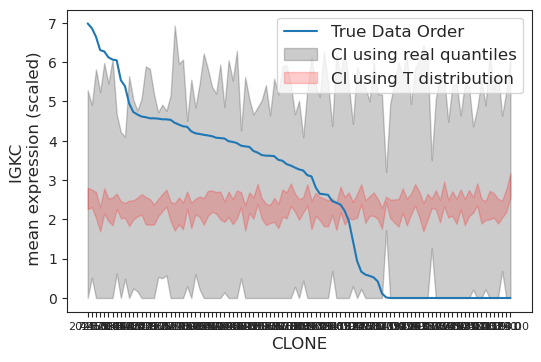

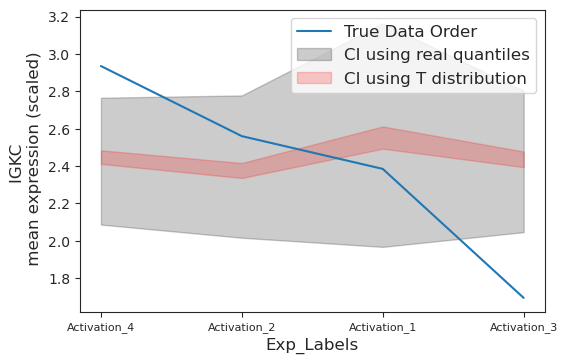

In [33]:
data, shuffled_means = plotCI(df, adata.obs, 100, 'IGKC', 'CLONE', 0.95)
data, shuffled_means = plotCI(df, adata.obs, 100, 'IGKC', 'Exp_Labels', 0.95)

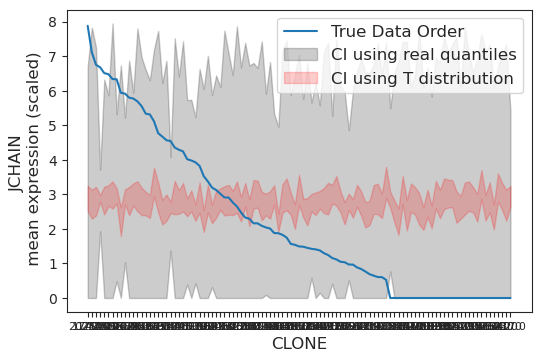

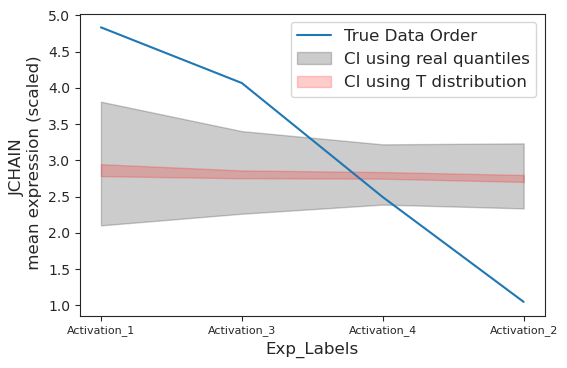

In [34]:
data = plotCI(df, adata.obs, 100, 'JCHAIN', 'CLONE', 0.95)
data = plotCI(df, adata.obs, 100, 'JCHAIN', 'Exp_Labels', 0.95)

In [30]:
gene_names = ['IGHG1', 'IGHG2', "IGHG4", 'IGHG3', 'IGHM', 'IGHD', 'IGHA1', 'IGHE', "IGHA2"]



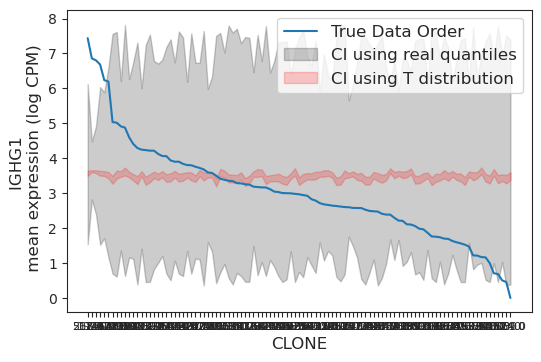

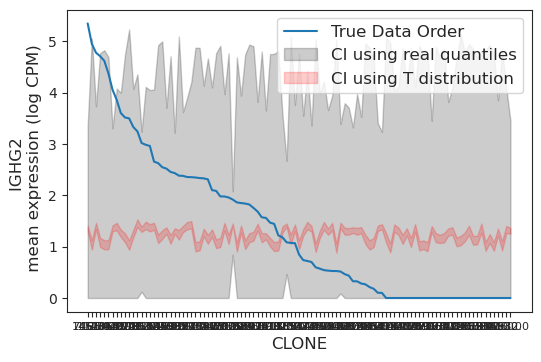

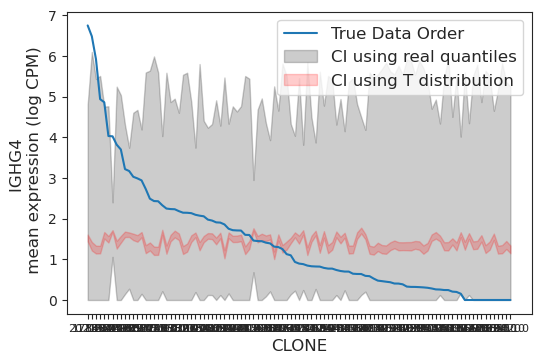

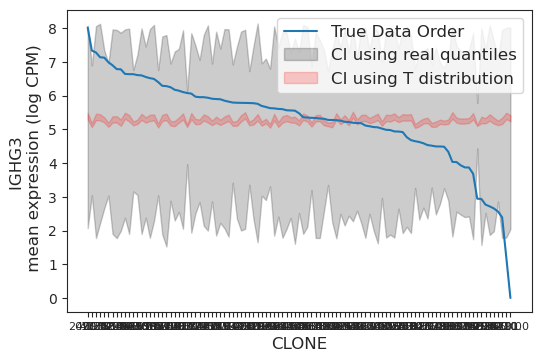

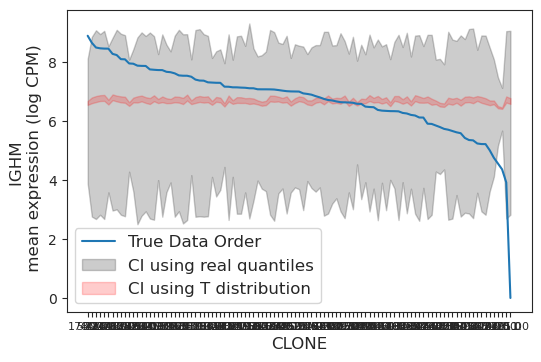

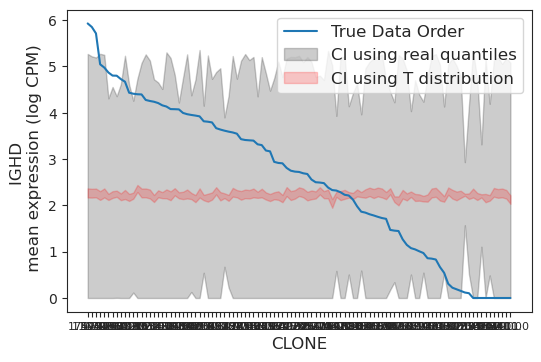

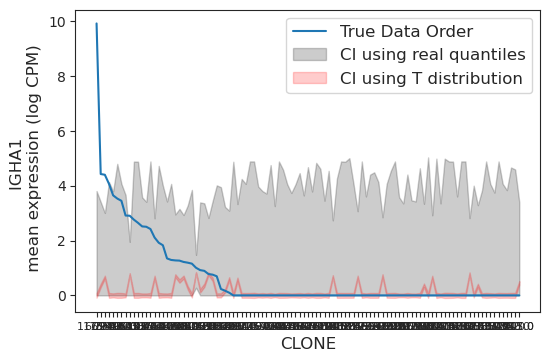

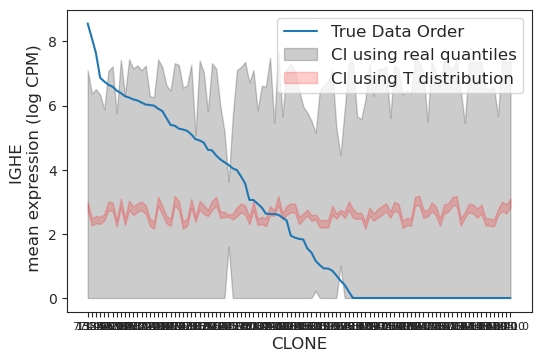

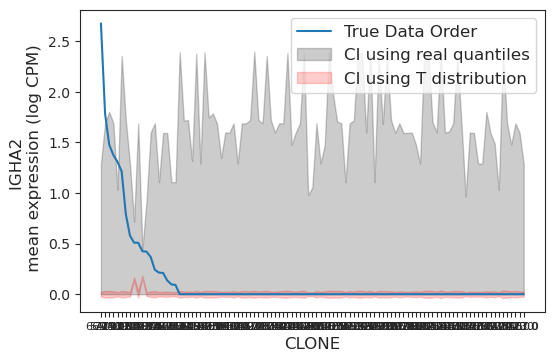

In [31]:
for gene in gene_names:
    data = plotCI(df, adata.obs, 1000, gene, 'CLONE', 0.95)

In [ ]:
for gene in gene_names:
    data = plotCI(df, adata.obs, 100, gene, 'CLONE', 0.95)
    data = plotCI(df, adata.obs, 100, gene, 'Exp_Labels', 0.95)

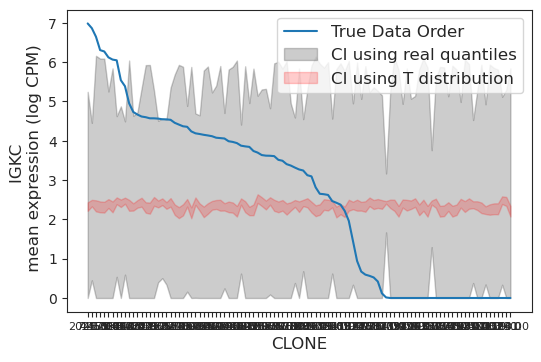

In [96]:
data, shuffledmeans = plotCI(df, adata.obs, 1000, 'IGKC', 'CLONE', 0.99)

In [ ]:
data, shuffledmeans = plotCI(df, adata.obs, 1000, 'IGKC', 'CLONE', 0.99)

for i in range(5):
    oneClone = shuffledmeans.iloc[i,:][:-5].values
    measurements = oneClone
    stats.probplot(measurements, dist = "norm", plot=pylab)

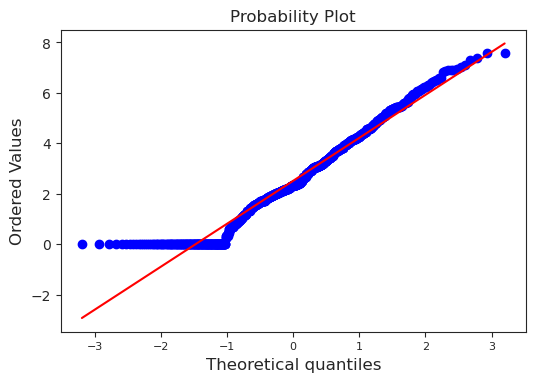

In [102]:
# 
import statsmodels
# generate t distribution
import scipy.stats as stats
import pylab
import numpy as np

oneClone = shuffledmeans.iloc[2,:][:-5].values

measurements = oneClone
#measurements = np.random.normal(loc = oneClone.mean(), scale = oneClone.std(), size = 1000)
g = stats.probplot(measurements, dist = "norm", plot=pylab)

## Division Number Code Protyping

In [45]:
# Mysterious 'None Division Numbers'
_df = adata_obs[adata_obs['DivisionNumber'] == 'None']

_df['CTV: Brilliant Violet 421-A-Compensated']

In [159]:
# Just get rid of them for the prototyping 
test_df = adata_obs[adata_obs['DivisionNumber'] != 'None']

In [160]:
# Add Division as Quantity (so I can add them to get a bin)
test_df['DivisionQuantize'] = test_df['DivisionNumber'].str.replace('Max', '6').astype(int)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [222]:
genes = tests.sort_values('score')['gene'][:200]

In [223]:
df_highlyvar = df[list(adata.var.index[adata.var.highly_variable == True])]
df_highlyexpressed = df[list(adata.var.index[adata.var.n_cells > 200])]
df_clonalgenes = df[genes]

In [172]:
test_df.shape

(323, 99)

In [68]:
import itertools

In [191]:
def DivCorrProto(df, obsdf):
    # Could pack a tuple with all these values then unpack it as a dataframe? 
    # TODO add the comparisons as a column 
    
    # Hacky, make sure that indices (cells) are the same set
    df = df[df.index.isin(obsdf.index)]
    Clone_Pearsons = []
    NonClone_Pearsons = []
    Clone_DivSum = []
    NonClone_DivSum = []

    NonClone_Cell1s = []
    NonClone_Cell2s = []
    
    for combo in itertools.combinations(df.index, 2):
        cell1 = combo[0]
        cell2 = combo[1]
        #print(cell1, cell2)
        #print(df.loc[cell1])
        #print(df.loc[cell2])
        pearson= np.corrcoef(df.loc[cell1], df.loc[cell2])[0][1]
        
        # Clonal Membership Test
        if obsdf.loc[cell1].CLONE == obsdf.loc[cell2].CLONE:
            Clone_Pearsons.append(pearson)
            Clone_DivSum.append(obsdf.loc[cell1].DivisionQuantize + obsdf.loc[cell2].DivisionQuantize)
            #Clone_Comp.append(())
        else:
            NonClone_Pearsons.append(pearson)
            NonClone_DivSum.append(obsdf.loc[cell1].DivisionQuantize + obsdf.loc[cell2].DivisionQuantize)

    dfCombined = makeDf(Clone_Pearsons, Clone_DivSum, NonClone_Pearsons, NonClone_DivSum)       
    
    return dfCombined
    
def makeDf(CP, CDS, NCP, NCDS):
    
    df_Clonal = pd.DataFrame([CP, CDS]).T

    df_Clonal.columns = ['Pearson', 'DivisionSum']
    df_Clonal['CLONAL'] = True

    df_NonClonal = pd.DataFrame([NCP, NCDS]).T
    df_NonClonal.columns = ['Pearson', 'DivisionSum']
    df_NonClonal['CLONAL'] = False
    dfCombined = pd.concat([df_Clonal, df_NonClonal])
    dfCombined['Relatedness'] = dfCombined.DivisionSum.astype('category')
    return dfCombined

In [198]:
dfplot = DivCorrProto(df_highly_var, test_df)

In [201]:
dfplot

,Pearson,DivisionSum,CLONAL,Relatedness
0,0.603848,10.0,True,10.0
1,0.517983,9.0,True,9.0
2,0.965962,3.0,True,3.0
3,0.586932,5.0,True,5.0
4,0.600462,9.0,True,9.0
...,...,...,...,...
50968,0.389482,12.0,False,12.0
50969,0.449028,12.0,False,12.0
50970,0.277220,12.0,False,12.0
50971,0.314138,12.0,False,12.0


In [202]:
dfplot['Hue'] = dfplot.CLONAL.astype('category')

In [209]:
dfplot['Dummy'] = ' '

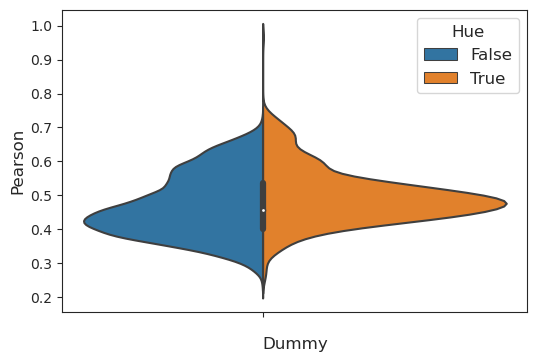

In [214]:
fig, ax = plt.subplots(1,1)

sns.violinplot(data = dfplot, x = 'Dummy', y = 'Pearson', split=True, hue = 'Hue' )

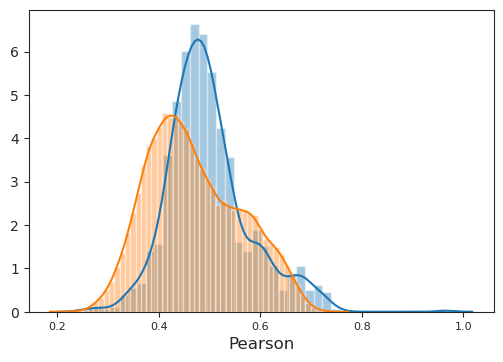

In [217]:
Related = dfplot[dfplot.CLONAL == True]
Unrelated = dfplot[dfplot.CLONAL == False]
sns.distplot(Related.Pearson)
sns.distplot(Unrelated.Pearson)

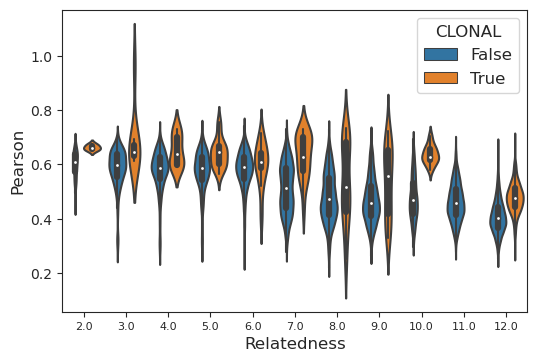

In [152]:
sns.violinplot(data = dfplot, y = 'Pearson', x = 'Relatedness', hue = 'CLONAL')

In [183]:
dfPlot = DivCorrProto(df_highlyexpressed, test_df)

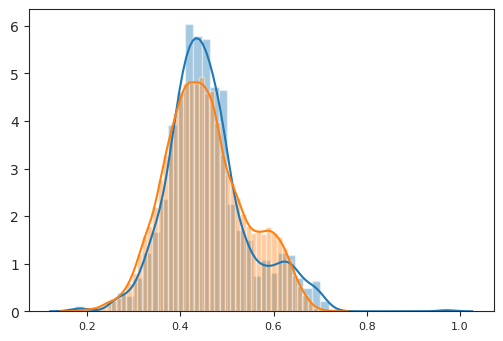

In [186]:
sns.distplot(CP)
sns.distplot(NCP)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


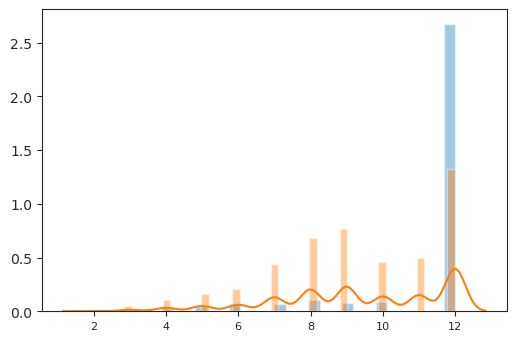

In [194]:
sns.distplot(CDS)
sns.distplot(NCDS)

In [192]:
dfplot = makeDf(CP, CDS, NCP, NCDS)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in exp
  result[i] = sum(exp(-energy)*self.weights, axis=0)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in multiply
  result[i] = sum(exp(-energy)*self.weights, axis=0)


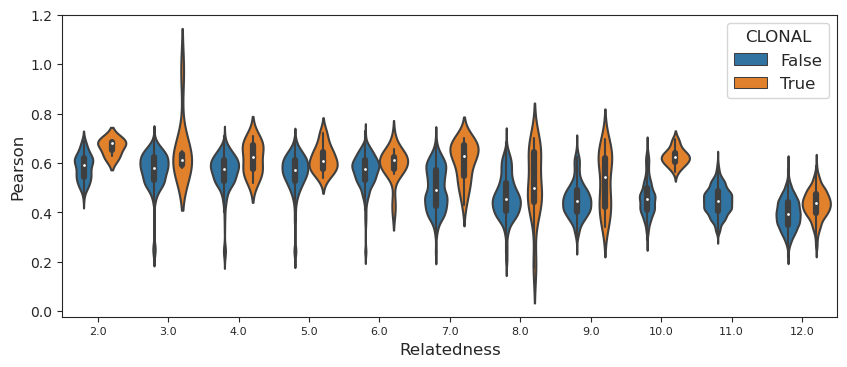

In [195]:
fig, ax = plt.subplots(1,1, figsize = (10, 4))
sns.violinplot(data = dfplot, y = 'Pearson', x = 'Relatedness', hue = 'CLONAL')

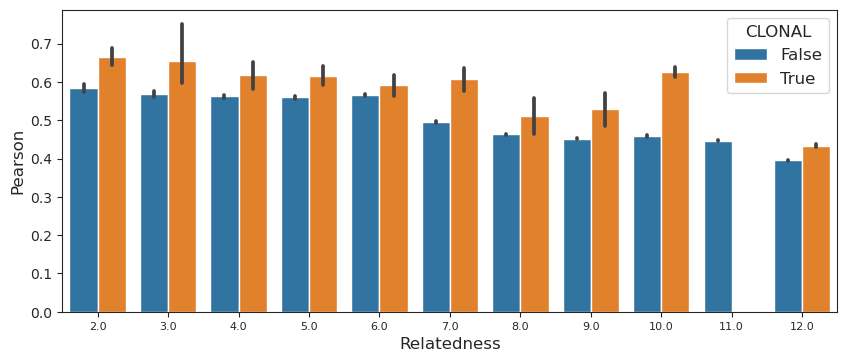

In [197]:
fig, ax = plt.subplots(1,1, figsize = (10, 4))
sns.barplot(data = dfplot, y = 'Pearson', x = 'Relatedness', hue = 'CLONAL')

In [225]:
dfplot = DivCorrProto(df_clonalgenes, test_df)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in exp
  result[i] = sum(exp(-energy)*self.weights, axis=0)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in multiply
  result[i] = sum(exp(-energy)*self.weights, axis=0)


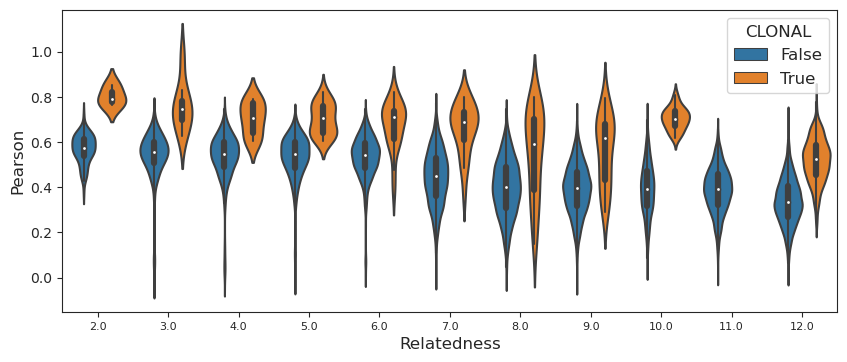

In [227]:
fig, ax = plt.subplots(1,1, figsize = (10, 4))
sns.violinplot(data = dfplot, y = 'Pearson', x = 'Relatedness', hue = 'CLONAL')

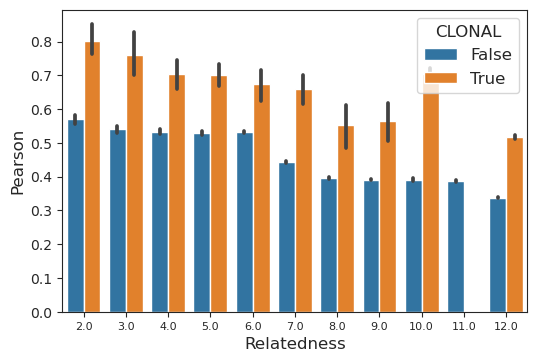

In [228]:
sns.barplot(data = dfplot, y = 'Pearson', x = 'Relatedness', hue = 'CLONAL')

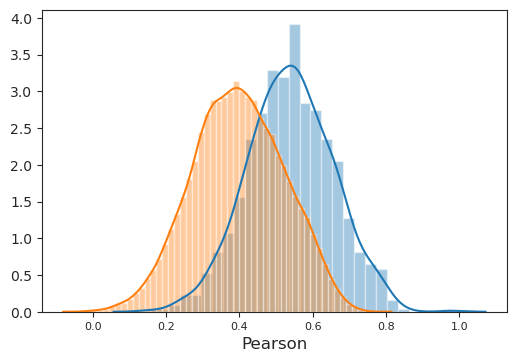

In [229]:
Related = dfplot[dfplot.CLONAL == True]
Unrelated = dfplot[dfplot.CLONAL == False]
sns.distplot(Related.Pearson)
sns.distplot(Unrelated.Pearson)